# 08. Causal Discovery, With Caveats

Causal discovery asks whether we can learn parts of a causal graph from data.

That is a tempting goal. In industry, we often have hundreds of behavioral, operational, product, and customer variables. We want to know which variables drive which others, where to intervene, and what should be treated as a confounder, mediator, proxy, or outcome.

But causal discovery is not a substitute for causal design. It is a way to generate, constrain, and stress-test causal hypotheses under assumptions.

This notebook is intentionally cautious. We will implement small discovery ideas from scratch, study what they can recover, and then break them with latent confounding, selection, faithfulness failures, measurement choices, and time-ordering mistakes.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain what causal discovery tries to learn from observational data.
- Distinguish a DAG, a skeleton, a v-structure, and a Markov equivalence class.
- Explain the causal Markov, faithfulness, causal sufficiency, and acyclicity assumptions.
- Use conditional independence patterns to reason about chains, forks, and colliders.
- Implement a small PC-style skeleton search for linear Gaussian data.
- Explain why many edge directions are not identifiable from conditional independences alone.
- Demonstrate how latent confounding and selection bias can mislead discovery.
- Compare constraint-based, score-based, functional-model, and time-series discovery ideas.
- Use causal discovery responsibly as part of an industry causal workflow.


## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, networkx, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import itertools
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def draw_dag(edges, nodes=None, title=None, bidirected=None):
    """Draw the dag graph.
    
    Inputs:
    - `edges`: directed or undirected graph edges represented as node pairs.
    - `nodes`: optional list of graph nodes to display even if they have no edge.
    - `title`: plot or graph title displayed above the figure.
    - `bidirected`: pairs of nodes displayed with bidirected arcs for latent-confounding notation.
    Returns: a Graphviz DAG with the requested directed and bidirected edges."""
    dot = Digraph(graph_attr={"rankdir": "LR"})
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")
    if title:
        dot.attr(label=title, labelloc="t")
    if nodes is None:
        nodes = sorted(set([v for edge in edges for v in edge]))
    for node in nodes:
        dot.node(str(node), str(node))
    for parent, child in edges:
        dot.edge(str(parent), str(child))
    if bidirected:
        for left, right in bidirected:
            dot.edge(str(left), str(right), dir="both", color="#de2d26", style="dashed")
    return dot


def residualize(y, controls):
    """Remove linear control variation from a variable before independence testing.
    
    Inputs:
    - `y`: numeric vector being residualized against the supplied controls.
    - `controls`: control variables used to residualize a variable before independence testing.
    Returns: a NumPy residual vector after projecting the variable on the control matrix."""
    y = np.asarray(y, dtype=float)
    if controls is None or controls.shape[1] == 0:
        return y - y.mean()
    X = sm.add_constant(np.asarray(controls, dtype=float), has_constant="add")
    model = sm.OLS(y, X).fit()
    return model.resid


def partial_corr_test(df, x, y, cond=()):
    """Run a partial-correlation conditional independence test.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `x`: first variable name in the conditional-independence test.
    - `y`: second variable name in the conditional-independence test.
    - `cond`: conditioning-set variable names used in the partial-correlation test.
    Returns: the partial correlation and p-value for the tested variable pair conditional on the selected controls."""
    cond = list(cond)
    if len(cond) == 0:
        r, p = stats.pearsonr(df[x], df[y])
        return r, p
    rx = residualize(df[x], df[cond].to_numpy())
    ry = residualize(df[y], df[cond].to_numpy())
    r, p = stats.pearsonr(rx, ry)
    return r, p


def format_edge(edge):
    """Compute format edge for the causal discovery with caveats example.
    
    Inputs:
    - `edge`: single graph edge represented as a pair of node names.
    Returns: a readable edge label for tables and diagnostics."""
    return " -- ".join(sorted(edge))


### Dataset and Experiment Setup

This notebook uses generated graph data because causal discovery must be checked against a known data-generating structure. The units are generic observations from operational, marketing, product, or support systems. The early examples use simple chains, forks, and colliders so the logic of conditional independence is visible. Later examples use a less friendly operational system with latent demand, logging selection, nonlinear response, measurement noise, time dependence, and intervention checks.

There is no external real dataset here. That is intentional. A real observational dataset would not reveal whether a discovered edge is correct, Markov equivalent, confounded, selected, or driven by measurement. The simulation lets the notebook compare the discovered skeleton with visible design edges while also showing why the output is not a final causal answer. The teaching goal is to treat discovery as hypothesis generation that must be paired with domain knowledge, timing, negative controls, and targeted interventions.


## 2. What Causal Discovery Is and Is Not

Causal discovery is the problem of learning causal structure from data, often with help from assumptions such as:

- conditional independences,
- temporal order,
- non-Gaussianity,
- additive noise structure,
- sparsity,
- known interventions,
- acyclicity.

It can be useful for:

- generating DAG hypotheses,
- screening variables for follow-up,
- finding surprising conditional independences,
- comparing candidate causal stories,
- designing better experiments.

It should not be used as:

- a button that turns a data table into truth,
- a replacement for subject-matter knowledge,
- proof that an observational association is causal,
- a way to avoid defining interventions and estimands.


| family | core signal | examples | main caveat |
|---|---|---|---|
| Constraint-based | Conditional independence tests | PC, FCI | Sensitive to testing error, hidden variables, faithfulness, and measurement choices. |
| Score-based | Search for graph with best penalized likelihood or score | GES, hill-climbing, Bayesian network search | Large search space; score equivalence and local optima can obscure direction. |
| Functional causal models | Asymmetry in cause-effect data-generating process | LiNGAM, additive noise models | Requires strong assumptions such as non-Gaussianity or additive noise. |
| Continuous optimization | Optimize over weighted adjacency matrices with acyclicity constraints | NOTEARS-style methods | Still depends on modeling assumptions and tuning choices. |
| Time-series discovery | Lagged predictive structure and conditional independence over time | Granger-style models, PCMCI | Predictive precedence is not automatically structural causality. |


## 3. The Assumption Stack

Causal discovery methods differ, but many rely on some version of the following assumptions.


| assumption | meaning | failure mode |
|---|---|---|
| Causal Markov condition | Each variable is independent of its non-effects given its direct causes. | Dependencies do not match the graph. |
| Faithfulness | All and only graph-implied independences appear in the distribution. | Path cancellations hide real causal paths. |
| Causal sufficiency | There are no unmeasured common causes among measured variables. | Latent confounding creates edges or directions that are not direct causes. |
| Acyclicity | The causal graph has no directed cycles. | Feedback systems violate DAG assumptions. |
| Correct variable definitions | Variables correspond to meaningful causal quantities at the right time scale. | Aggregates, proxies, and post-treatment variables distort structure. |
| Independent samples or modeled dependence | Rows are independent, or dependence is explicitly represented. | Network, panel, or time-series dependence creates misleading tests. |


The key professional habit is to state the assumptions before showing the graph.

A discovered graph should usually be labeled:

> Candidate causal structure under assumptions A, B, and C.


## 4. Chains, Forks, and Colliders

Most graphical discovery logic starts with conditional independence.

Three basic structures matter:

1. Chain: $X \rightarrow Z \rightarrow Y$
2. Fork: $X \leftarrow Z \rightarrow Y$
3. Collider: $X \rightarrow Z \leftarrow Y$

Chains and forks imply:

$$
X \not\!\perp\!\!\!\perp Y
$$

but:

$$
X \perp\!\!\!\perp Y \mid Z
$$

Colliders imply the opposite pattern:

$$
X \perp\!\!\!\perp Y
$$

but:

$$
X \not\!\perp\!\!\!\perp Y \mid Z
$$


In [2]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4808)
n = 5000

chain = pd.DataFrame({"X": rng.normal(size=n)})
chain["Z"] = 0.9 * chain["X"] + rng.normal(size=n)
chain["Y"] = 0.9 * chain["Z"] + rng.normal(size=n)

fork = pd.DataFrame({"Z": rng.normal(size=n)})
fork["X"] = 0.9 * fork["Z"] + rng.normal(size=n)
fork["Y"] = 0.9 * fork["Z"] + rng.normal(size=n)

collider = pd.DataFrame({"X": rng.normal(size=n), "Y": rng.normal(size=n)})
collider["Z"] = 0.9 * collider["X"] + 0.9 * collider["Y"] + rng.normal(size=n)

ci_rows = []
for name, df in [("Chain X -> Z -> Y", chain), ("Fork X <- Z -> Y", fork), ("Collider X -> Z <- Y", collider)]:
    marginal_r, marginal_p = partial_corr_test(df, "X", "Y", cond=())
    conditional_r, conditional_p = partial_corr_test(df, "X", "Y", cond=("Z",))
    ci_rows.extend(
        [
            {
                "structure": name,
                "test": "marginal X-Y",
                "correlation": marginal_r,
                "p_value": marginal_p,
            },
            {
                "structure": name,
                "test": "conditional X-Y | Z",
                "correlation": conditional_r,
                "p_value": conditional_p,
            },
        ]
    )

ci_table = pd.DataFrame(ci_rows)
ci_table


,structure,test,correlation,p_value
0,Chain X -> Z -> Y,marginal X-Y,0.500,0.000
1,Chain X -> Z -> Y,conditional X-Y | Z,-0.022,0.112
2,Fork X <- Z -> Y,marginal X-Y,0.459,0.000
3,Fork X <- Z -> Y,conditional X-Y | Z,0.015,0.302
4,Collider X -> Z <- Y,marginal X-Y,-0.001,0.952
5,Collider X -> Z <- Y,conditional X-Y | Z,-0.462,0.000


This result deserves a close look because it turns the method into something we can audit. Learned graphs are best treated as structured hypotheses that organize assumptions for review.

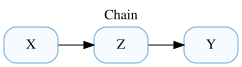

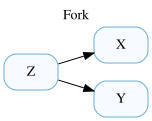

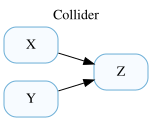

In [3]:
graphs = [
    draw_dag([("X", "Z"), ("Z", "Y")], title="Chain"),
    draw_dag([("Z", "X"), ("Z", "Y")], title="Fork"),
    draw_dag([("X", "Z"), ("Y", "Z")], title="Collider"),
]

for graph in graphs:
    display(graph)


The result matters when it changes the next decision. Discovery helps prioritize causal questions, but domain knowledge and intervention evidence still discipline the graph.

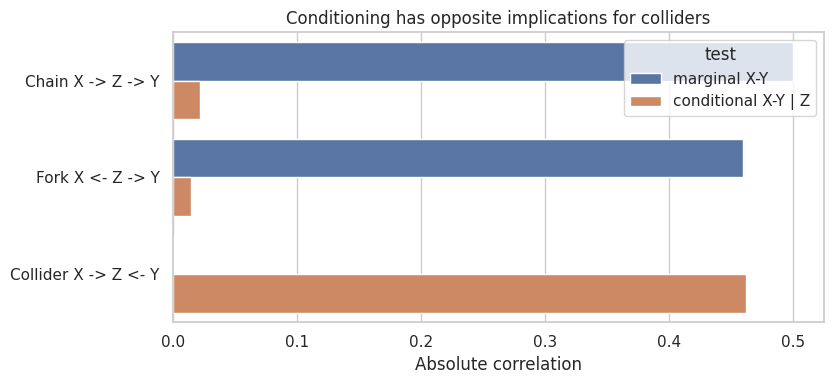

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4))
plot_df = ci_table.copy()
plot_df["abs_correlation"] = plot_df["correlation"].abs()
sns.barplot(data=plot_df, y="structure", x="abs_correlation", hue="test", ax=ax)
ax.set_title("Conditioning has opposite implications for colliders")
ax.set_xlabel("Absolute correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


This is the heart of many discovery methods:

- remove edges when conditional independence appears,
- orient unshielded colliders when conditioning behavior requires it,
- leave unresolved directions when multiple DAGs imply the same independences.


## 5. Markov Equivalence

Different DAGs can imply the same conditional independence structure.

For example:

$$
X \rightarrow Z \rightarrow Y
$$

and:

$$
X \leftarrow Z \rightarrow Y
$$

both imply $X \perp\!\!\!\perp Y \mid Z$. Conditional independences alone cannot choose between them.

But:

$$
X \rightarrow Z \leftarrow Y
$$

has a collider at $Z$, so it is distinguishable from the chain and fork.


| DAG | skeleton | unshielded collider? | key independence | equivalence class |
|---|---|---|---|---|
| X -> Z -> Y | X - Z - Y | No | X independent of Y given Z | Same as fork |
| X <- Z -> Y | X - Z - Y | No | X independent of Y given Z | Same as chain |
| X -> Z <- Y | X - Z - Y | Yes | X independent of Y marginally, dependent given Z | Distinct |


This is why many discovery algorithms output a partially directed graph. The data may identify an equivalence class, not one unique causal story.


## 6. A Small PC-Style Skeleton Search

The PC algorithm is a classic constraint-based causal discovery method. The full algorithm has several steps. Here we implement a tiny version focused on the skeleton:

1. Start with a complete undirected graph.
2. Test marginal independences and remove edges.
3. Test conditional independences with increasingly large conditioning sets.
4. Record the separating set that removed each edge.
5. Use separating sets to orient unshielded colliders.

This is a teaching implementation, not a production implementation.


In [5]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def neighbors(edge_set, node):
    """Compute neighbors for the causal discovery with caveats example.
    
    Inputs:
    - `edge_set`: set of current undirected edges in the PC-style skeleton search.
    - `node`: node whose adjacent neighbors are being requested.
    Returns: the set of adjacent nodes in the current undirected edge set."""
    out = set()
    for left, right in edge_set:
        if left == node:
            out.add(right)
        elif right == node:
            out.add(left)
    return out


def canonical_pair(x, y):
    """Compute canonical pair for the causal discovery with caveats example.
    
    Inputs:
    - `x`: first node name in an undirected graph edge.
    - `y`: second node name in an undirected graph edge.
    Returns: a sorted two-node tuple so undirected edges have one stable representation."""
    return tuple(sorted((x, y)))


def pc_skeleton(df, variables, alpha=0.01, max_cond_set=3):
    """Run a small PC-style skeleton search using partial-correlation tests.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `variables`: list of variable names included in the causal-discovery search.
    - `alpha`: significance level or exposure saturation parameter, depending on the function.
    - `max_cond_set`: largest conditioning-set size allowed in the PC-style search.
    Returns: the retained undirected edge set, separating sets, and a test-log DataFrame."""
    edge_set = {canonical_pair(x, y) for x, y in itertools.combinations(variables, 2)}
    sep_sets = {}
    test_log = []
    
    for cond_size in range(max_cond_set + 1):
        removed_this_round = True
        while removed_this_round:
            removed_this_round = False
            for x, y in list(edge_set):
                candidate_neighbors = list((neighbors(edge_set, x) - {y}) | (neighbors(edge_set, y) - {x}))
                if len(candidate_neighbors) < cond_size:
                    continue
                for cond in itertools.combinations(candidate_neighbors, cond_size):
                    r, p = partial_corr_test(df, x, y, cond=cond)
                    test_log.append(
                        {
                            "x": x,
                            "y": y,
                            "conditioning_set": cond,
                            "cond_size": cond_size,
                            "partial_corr": r,
                            "p_value": p,
                        }
                    )
                    if p > alpha:
                        edge_set.remove((x, y))
                        sep_sets[canonical_pair(x, y)] = tuple(cond)
                        removed_this_round = True
                        break
    return edge_set, sep_sets, pd.DataFrame(test_log)


def orient_v_structures(variables, edge_set, sep_sets):
    """Orient unshielded colliders from a learned skeleton and separating sets.
    
    Inputs:
    - `variables`: list of variable names included in the causal-discovery search.
    - `edge_set`: set of current undirected edges in the PC-style skeleton search.
    - `sep_sets`: separating sets found by conditional-independence tests.
    Returns: directed collider edges and the remaining undirected edges."""
    directed = []
    undirected = set(edge_set)
    for x, z in itertools.combinations(variables, 2):
        if canonical_pair(x, z) in edge_set:
            continue
        common = neighbors(edge_set, x) & neighbors(edge_set, z)
        sep = set(sep_sets.get(canonical_pair(x, z), ()))
        for y in common:
            if y not in sep:
                directed.append((x, y))
                directed.append((z, y))
                undirected.discard(canonical_pair(x, y))
                undirected.discard(canonical_pair(z, y))
    return directed, undirected


def draw_partial_graph(variables, directed_edges, undirected_edges, title=None):
    """Draw the partial graph graph.
    
    Inputs:
    - `variables`: list of variable names included in the causal-discovery search.
    - `directed_edges`: directed graph edges used in a DAG or partially directed graph.
    - `undirected_edges`: undirected graph edges that remain unoriented after discovery.
    - `title`: plot or graph title displayed above the figure.
    Returns: a Graphviz graph that shows directed and undirected discovery output."""
    dot = Digraph(graph_attr={"rankdir": "LR"})
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")
    if title:
        dot.attr(label=title, labelloc="t")
    for node in variables:
        dot.node(node, node)
    for left, right in sorted(undirected_edges):
        dot.edge(left, right, dir="none", color="#636363")
    for left, right in directed_edges:
        dot.edge(left, right, color="#2b8cbe")
    return dot


Now simulate a linear Gaussian DAG:

$$
A \rightarrow B
$$

$$
A \rightarrow C
$$

$$
B \rightarrow D
$$

$$
C \rightarrow D
$$

$$
D \rightarrow E
$$


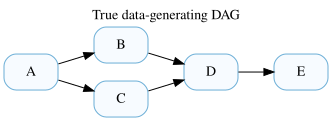

In [6]:
rng = np.random.default_rng(4809)
n = 4500

dag_df = pd.DataFrame({"A": rng.normal(size=n)})
dag_df["B"] = 0.90 * dag_df["A"] + rng.normal(size=n)
dag_df["C"] = 0.75 * dag_df["A"] + rng.normal(size=n)
dag_df["D"] = 0.70 * dag_df["B"] + 0.65 * dag_df["C"] + rng.normal(size=n)
dag_df["E"] = 0.85 * dag_df["D"] + rng.normal(size=n)

variables = ["A", "B", "C", "D", "E"]
true_edges = {canonical_pair(*edge) for edge in [("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("D", "E")]}

edge_set, sep_sets, pc_log = pc_skeleton(dag_df, variables, alpha=0.001, max_cond_set=3)
directed_edges, remaining_undirected = orient_v_structures(variables, edge_set, sep_sets)

comparison = pd.DataFrame(
    [
        {
            "edge": format_edge(edge),
            "true_edge": edge in true_edges,
            "pc_skeleton_edge": edge in edge_set,
        }
        for edge in sorted(set(true_edges) | set(edge_set))
    ]
)

draw_dag([("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("D", "E")], title="True data-generating DAG")


A result like this should lead to a concrete follow-up. The graph is useful when it makes assumptions easier to challenge.

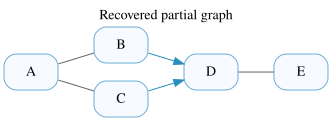

,edge,true_edge,pc_skeleton_edge
0,A -- B,True,True
1,A -- C,True,True
2,B -- D,True,True
3,C -- D,True,True
4,D -- E,True,True


In [7]:
display(draw_partial_graph(variables, directed_edges, remaining_undirected, title="Recovered partial graph"))

comparison


Here the method has to be judged against the design and the evidence. Learned graphs are best treated as structured hypotheses that organize assumptions for review.

In [8]:
sep_table = pd.DataFrame(
    [
        {
            "removed_pair": f"{x} -- {y}",
            "separating_set": ", ".join(cond) if cond else "(empty)",
        }
        for (x, y), cond in sep_sets.items()
    ]
).sort_values("removed_pair")

sep_table


,removed_pair,separating_set
4,A -- D,"B, C"
2,A -- E,D
1,B -- C,A
3,B -- E,D
0,C -- E,D


### Interpretation

In this friendly simulation, the skeleton search recovers the main adjacencies. It also orients the unshielded collider:

$$
B \rightarrow D \leftarrow C
$$

because $B$ and $C$ are not adjacent and $D$ was not in their separating set.

But several directions remain unresolved. This is not a failure of the implementation. Conditional independence alone often identifies a Markov equivalence class, not a unique DAG.


## 7. Testing Error and Sample Size

Conditional independence testing is statistical. With finite data:

- true edges can be removed,
- false edges can remain,
- orientation decisions can change,
- results can be sensitive to the significance threshold.

Let us rerun the same skeleton procedure with smaller sample sizes.


In [9]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_friendly_dag(n, seed):
    """Simulate the friendly dag data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)
    out = pd.DataFrame({"A": rng.normal(size=n)})
    out["B"] = 0.90 * out["A"] + rng.normal(size=n)
    out["C"] = 0.75 * out["A"] + rng.normal(size=n)
    out["D"] = 0.70 * out["B"] + 0.65 * out["C"] + rng.normal(size=n)
    out["E"] = 0.85 * out["D"] + rng.normal(size=n)
    return out


sample_rows = []
for sample_size in [150, 300, 800, 2000, 4500]:
    for rep in range(20):
        tmp = simulate_friendly_dag(sample_size, seed=10_000 + sample_size + rep)
        edges_hat, _, _ = pc_skeleton(tmp, variables, alpha=0.001, max_cond_set=3)
        true_positive = len(edges_hat & true_edges)
        false_positive = len(edges_hat - true_edges)
        false_negative = len(true_edges - edges_hat)
        sample_rows.append(
            {
                "sample_size": sample_size,
                "rep": rep,
                "true_positive_edges": true_positive,
                "false_positive_edges": false_positive,
                "false_negative_edges": false_negative,
            }
        )

sample_sensitivity = pd.DataFrame(sample_rows)
sample_summary = sample_sensitivity.groupby("sample_size", as_index=False).agg(
    mean_true_positive=("true_positive_edges", "mean"),
    mean_false_positive=("false_positive_edges", "mean"),
    mean_false_negative=("false_negative_edges", "mean"),
)
sample_summary


,sample_size,mean_true_positive,mean_false_positive,mean_false_negative
0,150,4.350,0.000,0.650
1,300,4.950,0.000,0.050
2,800,5.000,0.000,0.000
3,2000,5.000,0.000,0.000
4,4500,5.000,0.000,0.000


The point is to connect the number to the decision it supports. Discovery helps prioritize causal questions, but domain knowledge and intervention evidence still discipline the graph.

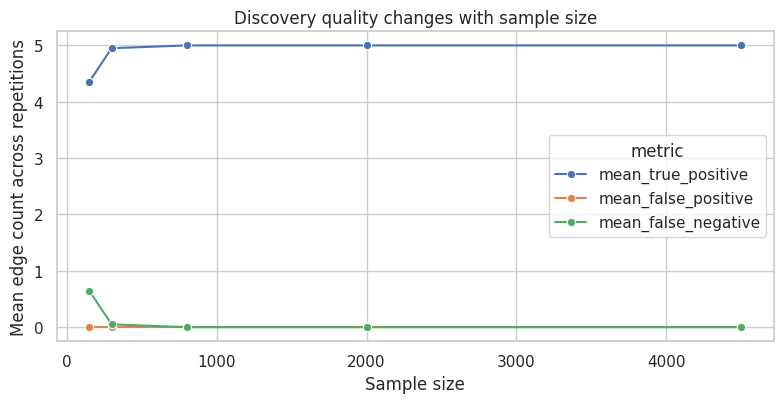

In [10]:
plot_df = sample_summary.melt(
    id_vars="sample_size",
    value_vars=["mean_true_positive", "mean_false_positive", "mean_false_negative"],
    var_name="metric",
    value_name="mean_count",
)

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.lineplot(data=plot_df, x="sample_size", y="mean_count", hue="metric", marker="o", ax=ax)
ax.set_title("Discovery quality changes with sample size")
ax.set_xlabel("Sample size")
ax.set_ylabel("Mean edge count across repetitions")
plt.tight_layout()
plt.show()


This is one reason discovery should be paired with stability checks. If small changes in sample, threshold, or variable set produce very different graphs, the discovered structure should be treated as exploratory.


## 8. Stress Test: A Less Friendly Operational System

The friendly DAG is useful for learning the mechanics, but real operational data is usually messier. Now simulate a system with latent demand, logging selection, nonlinear response, and measurement noise. The observed variables still have a true causal structure, but several important forces are hidden from the analyst. This is closer to what happens when teams run discovery on product, marketing, support, and retention data pulled from production logs.


In [11]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_operational_discovery_data(n=7000, seed=4810):
    """Simulate operational logs for a harder causal-discovery stress test.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with observed marketing, traffic, support load, product usage, retention, and logging-selection indicators."""
    rng = np.random.default_rng(seed)
    latent_demand = rng.normal(0, 1, size=n)
    launch_pressure = rng.normal(0, 1, size=n)
    marketing = 0.70 * latent_demand + 0.35 * launch_pressure + rng.normal(0, 1.0, size=n)
    traffic = 0.85 * marketing + 0.75 * latent_demand + rng.normal(0, 1.0, size=n)
    support_load = 0.50 * launch_pressure + 0.45 * traffic + rng.normal(0, 1.1, size=n)
    product_usage = 0.70 * traffic - 0.35 * support_load + 0.30 * latent_demand + rng.normal(0, 1.0, size=n)
    retention = 0.65 * product_usage - 0.45 * support_load + 0.55 * latent_demand + rng.normal(0, 1.0, size=n)
    logged_score = 1.1 + 0.45 * traffic + 0.35 * support_load
    logged_probability = 1 / (1 + np.exp(-logged_score))
    logged = rng.binomial(1, logged_probability, size=n)
    return pd.DataFrame(
        {
            "Marketing": marketing,
            "Traffic": traffic,
            "SupportLoad": support_load,
            "ProductUsage": product_usage,
            "Retention": retention,
            "Logged": logged,
        }
    )


ops = simulate_operational_discovery_data()
ops_observed = ops.loc[ops["Logged"] == 1].copy()
ops_variables = ["Marketing", "Traffic", "SupportLoad", "ProductUsage", "Retention"]
ops_true_visible_edges = {
    canonical_pair("Marketing", "Traffic"),
    canonical_pair("Traffic", "SupportLoad"),
    canonical_pair("Traffic", "ProductUsage"),
    canonical_pair("SupportLoad", "ProductUsage"),
    canonical_pair("SupportLoad", "Retention"),
    canonical_pair("ProductUsage", "Retention"),
}

ops_edges, ops_sep_sets, ops_log = pc_skeleton(
    ops_observed[ops_variables],
    ops_variables,
    alpha=0.001,
    max_cond_set=3,
)

ops_comparison = pd.DataFrame(
    [
        {
            "edge": format_edge(edge),
            "visible_design_edge": edge in ops_true_visible_edges,
            "pc_skeleton_edge": edge in ops_edges,
        }
        for edge in sorted(set(ops_true_visible_edges) | set(ops_edges))
    ]
)

pd.Series(
    {
        "raw_rows": len(ops),
        "logged_rows_used_by_discovery": len(ops_observed),
        "logged_share": ops["Logged"].mean(),
        "visible_design_edges": len(ops_true_visible_edges),
        "discovered_skeleton_edges": len(ops_edges),
        "false_positive_visible_edges": len(ops_edges - ops_true_visible_edges),
        "missed_visible_edges": len(ops_true_visible_edges - ops_edges),
    }
)


raw_rows                        7,000.000
logged_rows_used_by_discovery   4,977.000
logged_share                        0.711
visible_design_edges                6.000
discovered_skeleton_edges           8.000
false_positive_visible_edges        2.000
missed_visible_edges                0.000
dtype: float64

Here the example becomes operational. The graph is useful when it makes assumptions easier to challenge.

In [12]:
ops_comparison


,edge,visible_design_edge,pc_skeleton_edge
0,Marketing -- SupportLoad,False,True
1,Marketing -- Traffic,True,True
2,ProductUsage -- Retention,True,True
3,ProductUsage -- SupportLoad,True,True
4,ProductUsage -- Traffic,True,True
5,Retention -- SupportLoad,True,True
6,Retention -- Traffic,False,True
7,SupportLoad -- Traffic,True,True


This stress test is intentionally uncomfortable. A discovered edge may reflect a direct visible relationship, an omitted latent driver, or the fact that the dataset only includes logged cases. That is the main lesson. Causal discovery can organize hypotheses, but operational data usually needs subject-matter review, timing checks, negative controls, and targeted interventions before the graph becomes decision evidence.


## 8. Score-Based Search: A Tiny Exhaustive Example

Score-based methods search over graphs and choose a graph with a good penalized fit.

For a small number of variables, we can enumerate all possible directed graphs, keep only acyclic ones, and score each graph with a linear-Gaussian BIC:

$$
BIC = \sum_{j} \left[
n \log\left(\frac{RSS_j}{n}\right) + k_j \log(n)
\right]
$$

where $RSS_j$ is the residual sum of squares for node $j$ regressed on its parents.


In [13]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
score_vars = ["A", "B", "C", "D"]
score_df = dag_df[score_vars].copy()


def graph_bic(df, directed_edges, variables):
    """Score a candidate DAG with a decomposed linear-Gaussian BIC criterion.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `directed_edges`: directed graph edges used in a DAG or partially directed graph.
    - `variables`: list of variable names included in the causal-discovery search.
    Returns: a scalar BIC score summed over child regressions in the candidate graph."""
    n = len(df)
    total = 0.0
    for child in variables:
        parents = [p for p, c in directed_edges if c == child]
        y = df[child].to_numpy()
        if parents:
            X = sm.add_constant(df[parents].to_numpy(), has_constant="add")
        else:
            X = np.ones((n, 1))
        model = sm.OLS(y, X).fit()
        rss = np.sum(model.resid ** 2)
        k = X.shape[1]
        total += n * np.log(rss / n) + k * np.log(n)
    return total


def enumerate_dags(df, variables, max_parents=3):
    """Enumerate and score small DAGs for the score-based discovery example.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    - `variables`: list of variable names included in the causal-discovery search.
    - `max_parents`: maximum number of parents allowed for a candidate DAG during enumeration.
    Returns: a DataFrame of acyclic candidate graphs sorted by BIC."""
    possible_edges = [(a, b) for a in variables for b in variables if a != b]
    rows = []
    for mask in range(2 ** len(possible_edges)):
        edges = [possible_edges[i] for i in range(len(possible_edges)) if (mask >> i) & 1]
        parent_counts = pd.Series([child for _, child in edges]).value_counts()
        if len(parent_counts) and parent_counts.max() > max_parents:
            continue
        G = nx.DiGraph()
        G.add_nodes_from(variables)
        G.add_edges_from(edges)
        if not nx.is_directed_acyclic_graph(G):
            continue
        rows.append(
            {
                "edges": tuple(sorted(edges)),
                "n_edges": len(edges),
                "bic": graph_bic(df, edges, variables),
            }
        )
    return pd.DataFrame(rows).sort_values("bic").reset_index(drop=True)


score_results = enumerate_dags(score_df, score_vars, max_parents=3)
top_score_graphs = score_results.head(8).copy()
top_score_graphs["edge_text"] = top_score_graphs["edges"].apply(lambda edges: ", ".join([f"{a}->{b}" for a, b in edges]))
top_score_graphs[["bic", "n_edges", "edge_text"]]


,bic,n_edges,edge_text
0,-175.489,4,"A->B, A->C, B->D, C->D"
1,-175.489,4,"A->B, B->D, C->A, C->D"
2,-175.489,4,"A->C, B->A, B->D, C->D"
3,-168.405,5,"A->B, A->C, A->D, B->D, C->D"
4,-168.405,5,"A->B, A->D, B->D, C->A, C->D"
5,-168.405,5,"A->C, A->D, B->A, B->D, C->D"
6,-168.365,5,"A->B, A->C, B->C, B->D, C->D"
7,-168.365,5,"B->A, B->C, B->D, C->A, D->C"


This output should make the next modeling choice easier to defend. Learned graphs are best treated as structured hypotheses that organize assumptions for review.

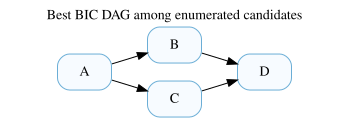

true_edges_on_A_B_C_D                  A->B, A->C, B->D, C->D
best_score_edges                       A->B, A->C, B->D, C->D
number_of_acyclic_candidates_scored                       543
dtype: object

In [14]:
best_edges = list(score_results.iloc[0]["edges"])
display(draw_dag(best_edges, nodes=score_vars, title="Best BIC DAG among enumerated candidates"))

pd.Series(
    {
        "true_edges_on_A_B_C_D": "A->B, A->C, B->D, C->D",
        "best_score_edges": ", ".join([f"{a}->{b}" for a, b in best_edges]),
        "number_of_acyclic_candidates_scored": len(score_results),
    }
)


The score-based search can recover a plausible graph in this friendly setting. But score-based search has its own caveats:

- many DAGs can score similarly,
- the best score depends on modeling assumptions,
- the search space grows rapidly,
- equivalent structures can be hard to distinguish,
- omitted variables can make a well-scored graph causally wrong.


## 9. Functional Causal Models: Direction From Asymmetry

Some methods use stronger assumptions to orient edges that conditional independence cannot orient.

LiNGAM assumes a linear acyclic model with independent non-Gaussian errors and no unobserved confounding. Under those assumptions, the direction can be identifiable.

Here is a simple two-variable illustration. We simulate:

$$
X \rightarrow Y
$$

with non-Gaussian $X$ and independent noise:

$$
Y = 1.7X + \epsilon
$$

If the model is correct, the residual from $Y$ regressed on $X$ should be independent of $X$. The reverse regression usually leaves a residual that still depends on $Y$.


In [15]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def distance_correlation(x, y):
    """Compute distance correlation as a nonlinear dependence diagnostic.
    
    Inputs:
    - `x`: first numeric vector in the nonlinear dependence diagnostic.
    - `y`: second numeric vector in the nonlinear dependence diagnostic.
    Returns: a scalar dependence score that is near zero under independence."""
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1, 1)
    a = np.abs(x - x.T)
    b = np.abs(y - y.T)
    A = a - a.mean(axis=0, keepdims=True) - a.mean(axis=1, keepdims=True) + a.mean()
    B = b - b.mean(axis=0, keepdims=True) - b.mean(axis=1, keepdims=True) + b.mean()
    dcov2 = np.mean(A * B)
    dvarx = np.mean(A * A)
    dvary = np.mean(B * B)
    return np.sqrt(max(dcov2, 0) / np.sqrt(dvarx * dvary))


rng = np.random.default_rng(4810)
n = 1200
X = rng.laplace(loc=0, scale=1, size=n)
Y = 1.7 * X + rng.normal(0, 1.0, size=n)
fm_df = pd.DataFrame({"X": X, "Y": Y})

forward = smf.ols("Y ~ X", data=fm_df).fit()
reverse = smf.ols("X ~ Y", data=fm_df).fit()

dependence_summary = pd.DataFrame(
    [
        {
            "direction": "Assume X -> Y",
            "residual": "Y residual after regressing on X",
            "dependence_between_predictor_and_residual": distance_correlation(fm_df["X"], forward.resid),
        },
        {
            "direction": "Assume Y -> X",
            "residual": "X residual after regressing on Y",
            "dependence_between_predictor_and_residual": distance_correlation(fm_df["Y"], reverse.resid),
        },
    ]
)

dependence_summary


,direction,residual,dependence_between_predictor_and_residual
0,Assume X -> Y,Y residual after regressing on X,0.045
1,Assume Y -> X,X residual after regressing on Y,0.095


The result is most useful when it shapes the next action. Discovery helps prioritize causal questions, but domain knowledge and intervention evidence still discipline the graph.

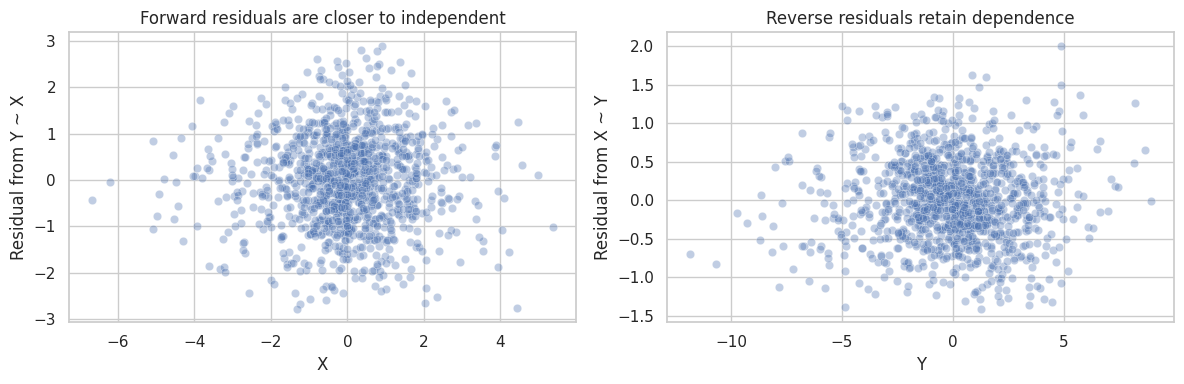

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=fm_df["X"], y=forward.resid, alpha=0.35, ax=axes[0])
axes[0].set_title("Forward residuals are closer to independent")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Residual from Y ~ X")

sns.scatterplot(x=fm_df["Y"], y=reverse.resid, alpha=0.35, ax=axes[1])
axes[1].set_title("Reverse residuals retain dependence")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("Residual from X ~ Y")

plt.tight_layout()
plt.show()


This kind of asymmetry is useful, but only under strong conditions. If the relationship is nonlinear, the noise is not independent, variables are coarsened, or there is an unmeasured common cause, the diagnostic can mislead.


## 10. Failure Mode: Latent Confounding

Now introduce an unmeasured variable $U$:

$$
U \rightarrow X
$$

and:

$$
U \rightarrow Y
$$

If $U$ is absent from the dataset, observational data can make $X$ and $Y$ look directly connected. A discovery algorithm may include an edge between them. That edge may reflect unmeasured confounding even when no direct causal effect exists.


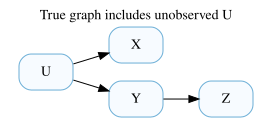

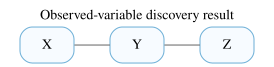

,observed_pair,edge_found,causal_warning
0,X -- Y,True,"Could be direct causation, latent confounding,..."
1,Y -- Z,True,"Could be direct causation, latent confounding,..."


In [17]:
rng = np.random.default_rng(4811)
n = 4000
latent = pd.DataFrame({"U": rng.normal(size=n)})
latent["X"] = 1.1 * latent["U"] + rng.normal(size=n)
latent["Y"] = 1.2 * latent["U"] + rng.normal(size=n)
latent["Z"] = 0.9 * latent["Y"] + rng.normal(size=n)

observed_latent = latent[["X", "Y", "Z"]]
latent_edges, latent_sep, _ = pc_skeleton(observed_latent, ["X", "Y", "Z"], alpha=0.001, max_cond_set=2)
latent_directed, latent_undirected = orient_v_structures(["X", "Y", "Z"], latent_edges, latent_sep)

display(draw_dag([("U", "X"), ("U", "Y"), ("Y", "Z")], nodes=["U", "X", "Y", "Z"], title="True graph includes unobserved U"))
display(draw_partial_graph(["X", "Y", "Z"], latent_directed, latent_undirected, title="Observed-variable discovery result"))

pd.DataFrame(
    [
        {
            "observed_pair": format_edge(edge),
            "edge_found": True,
            "causal_warning": "Could be direct causation, latent confounding, or both.",
        }
        for edge in sorted(latent_edges)
    ]
)


FCI-style algorithms are designed to represent possible latent confounding more explicitly than PC. But no algorithm can recover information that the data and assumptions do not contain.

learned graphs are best used as structured hypotheses. They organize assumptions for review while keeping domain knowledge in the loop.

## 11. Failure Mode: Selection Bias

Conditioning on a collider can create associations.

Suppose:

$$
X \rightarrow S \leftarrow Y
$$

where $S$ means "included in the dataset." If we only observe rows with $S=1$, then $X$ and $Y$ can become associated even if neither causes the other.

This is common in industry:

- only converted users enter a downstream dataset,
- only approved loans are observed,
- only active customers have telemetry,
- only investigated transactions receive fraud labels.


In [18]:
rng = np.random.default_rng(4812)
n = 80_000
selection = pd.DataFrame({"X": rng.normal(size=n), "Y": rng.normal(size=n)})
selection["selection_score"] = 0.9 * selection["X"] + 0.9 * selection["Y"] + rng.normal(size=n)
threshold = selection["selection_score"].quantile(0.82)
selection["S"] = (selection["selection_score"] > threshold).astype(int)
selected = selection.loc[selection["S"] == 1].copy()

selection_summary = pd.DataFrame(
    [
        {
            "sample": "Full generated population",
            "n": len(selection),
            "corr_XY": selection[["X", "Y"]].corr().iloc[0, 1],
        },
        {
            "sample": "Selected sample S=1",
            "n": len(selected),
            "corr_XY": selected[["X", "Y"]].corr().iloc[0, 1],
        },
    ]
)

selection_summary


,sample,n,corr_XY
0,Full generated population,80000,-0.006
1,Selected sample S=1,14400,-0.331


This is a checkpoint for the design and the estimate together. The graph is useful when it makes assumptions easier to challenge.

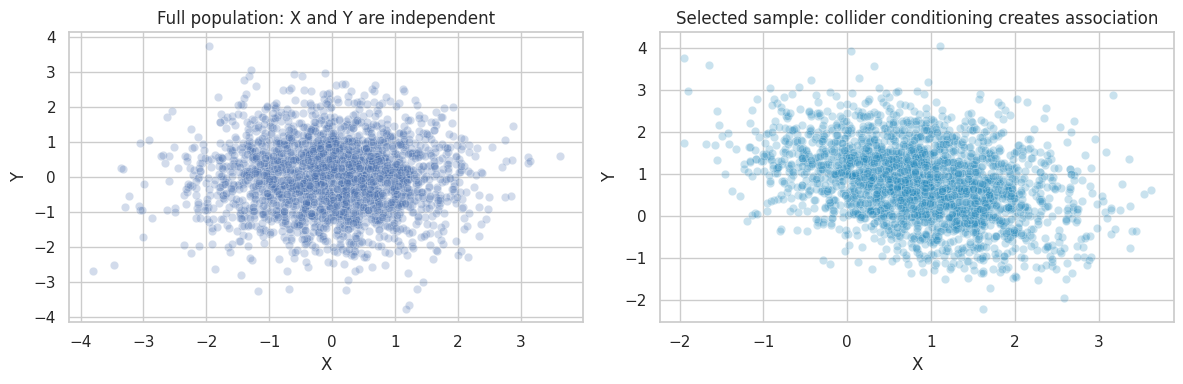

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=selection.sample(2500, random_state=1), x="X", y="Y", alpha=0.25, ax=axes[0])
axes[0].set_title("Full population: X and Y are independent")

sns.scatterplot(data=selected.sample(2500, random_state=2), x="X", y="Y", alpha=0.25, ax=axes[1], color="#2b8cbe")
axes[1].set_title("Selected sample: collider conditioning creates association")

plt.tight_layout()
plt.show()


If causal discovery is run only on the selected sample, it can interpret selection-induced dependence as structure. Before discovery, define the data-generating pipeline, not only the variables.

learned graphs are best used as structured hypotheses. They organize assumptions for review while keeping domain knowledge in the loop.

## 12. Failure Mode: Faithfulness Cancellation

Faithfulness can fail when multiple causal paths cancel.

Suppose:

$$
X \rightarrow Y
$$

and:

$$
X \rightarrow M \rightarrow Y
$$

If the direct path is positive and the indirect path is negative with similar magnitude, the marginal association between $X$ and $Y$ can be near zero even though causal effects exist.


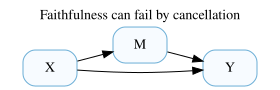

,test,correlation,p_value
0,Marginal X-Y,0.022,0.122
1,Conditional X-Y | M,0.695,0.000
2,Marginal X-M,0.958,0.000
3,Marginal M-Y,-0.183,0.000


In [20]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4813)
n = 5000
faith = pd.DataFrame({"X": rng.normal(size=n)})
faith["M"] = 1.0 * faith["X"] + rng.normal(0, 0.3, size=n)
faith["Y"] = 1.0 * faith["X"] - 1.0 * faith["M"] + rng.normal(0, 0.3, size=n)

faith_tests = pd.DataFrame(
    [
        {
            "test": "Marginal X-Y",
            "correlation": partial_corr_test(faith, "X", "Y")[0],
            "p_value": partial_corr_test(faith, "X", "Y")[1],
        },
        {
            "test": "Conditional X-Y | M",
            "correlation": partial_corr_test(faith, "X", "Y", cond=("M",))[0],
            "p_value": partial_corr_test(faith, "X", "Y", cond=("M",))[1],
        },
        {
            "test": "Marginal X-M",
            "correlation": partial_corr_test(faith, "X", "M")[0],
            "p_value": partial_corr_test(faith, "X", "M")[1],
        },
        {
            "test": "Marginal M-Y",
            "correlation": partial_corr_test(faith, "M", "Y")[0],
            "p_value": partial_corr_test(faith, "M", "Y")[1],
        },
    ]
)

display(draw_dag([("X", "Y"), ("X", "M"), ("M", "Y")], title="Faithfulness can fail by cancellation"))
faith_tests


The graph contains a direct causal path from $X$ to $Y$, but the marginal correlation is close to zero. Algorithms that rely on observed independences can remove real causal edges when faithfulness fails.

Exact cancellation is special, but near-cancellation is not exotic in business systems with offsetting mechanisms.


## 13. Time Series: Predictive Precedence Is Not Enough

Time order helps, but it does not solve everything.

If $X_t$ predicts $Y_{t+1}$, that is useful. But it may reflect:

- $X_t \rightarrow Y_{t+1}$,
- a common driver,
- seasonality,
- feedback,
- measurement timing,
- autocorrelation.

Time-series causal discovery needs assumptions about lags, stationarity, sampling frequency, hidden variables, and feedback.


In [21]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4814)
T = 500
ts_rows = []
u_prev = 0
x_prev = 0
y_prev = 0
for t in range(T):
    U = 0.7 * u_prev + rng.normal()
    X = 0.5 * x_prev + 0.9 * U + rng.normal()
    Y = 0.5 * y_prev + 0.8 * U + 0.0 * x_prev + rng.normal()
    ts_rows.append({"time": t, "U": U, "X": X, "Y": Y})
    u_prev, x_prev, y_prev = U, X, Y

ts = pd.DataFrame(ts_rows)
ts["X_lag"] = ts["X"].shift(1)
ts["Y_lag"] = ts["Y"].shift(1)
ts["U_lag"] = ts["U"].shift(1)
ts_model_naive = smf.ols("Y ~ Y_lag + X_lag", data=ts.dropna()).fit()
ts_model_with_driver = smf.ols("Y ~ Y_lag + X_lag + U_lag", data=ts.dropna()).fit()

ts_results = pd.DataFrame(
    {
        "Lag model without common driver": {
            "estimate": ts_model_naive.params["X_lag"],
            "std_error": ts_model_naive.bse["X_lag"],
            "p_value": ts_model_naive.pvalues["X_lag"],
        },
        "Lag model with common driver observed": {
            "estimate": ts_model_with_driver.params["X_lag"],
            "std_error": ts_model_with_driver.bse["X_lag"],
            "p_value": ts_model_with_driver.pvalues["X_lag"],
        },
    }
).T

ts_results


,estimate,std_error,p_value
Lag model without common driver,0.167,0.038,0.000
Lag model with common driver observed,0.011,0.044,0.801


The result matters because it changes what we would audit or do next. Learned graphs are best treated as structured hypotheses that organize assumptions for review.

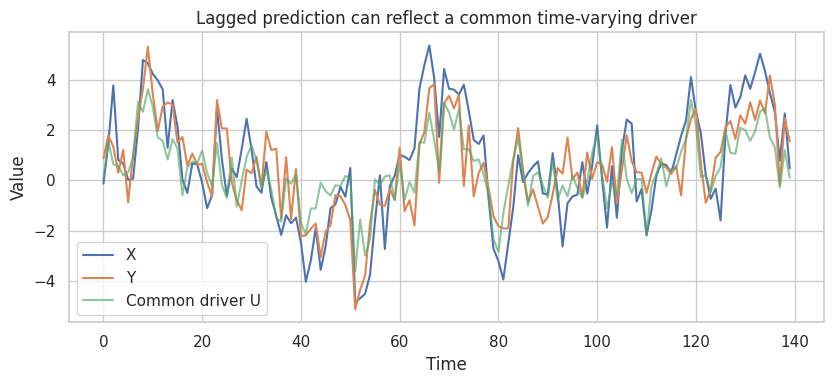

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 4))
plot_ts = ts.iloc[:140].copy()
sns.lineplot(data=plot_ts, x="time", y="X", ax=ax, label="X")
sns.lineplot(data=plot_ts, x="time", y="Y", ax=ax, label="Y")
sns.lineplot(data=plot_ts, x="time", y="U", ax=ax, label="Common driver U", alpha=0.65)
ax.set_title("Lagged prediction can reflect a common time-varying driver")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()


The naive lag model can make $X$ look predictive of future $Y$ even when the true structural coefficient from lagged $X$ to $Y$ is zero. Once the common driver is included, the apparent lag effect shrinks.

In real work, the common driver may be unobserved. That is why time order is helpful but not definitive.


## 14. Discovery Plus Interventions

Causal discovery is strongest when paired with interventions.

A practical workflow is:

1. Use observational data to propose a small number of plausible graphs.
2. Use domain constraints to rule out impossible directions.
3. Identify high-value uncertain edges.
4. Run an experiment or quasi-experiment to test those edges.
5. Update the graph and the intervention policy.


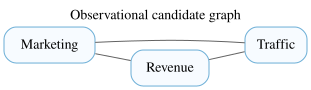

observational_candidate_edges                    Marketing -- Revenue, Marketing -- Traffic, Re...
experiment_effect_of_traffic_boost_on_revenue                                                1.073
experiment_p_value                                                                           0.000
dtype: object

In [23]:
rng = np.random.default_rng(4815)
n = 6000
obs = pd.DataFrame({"Marketing": rng.normal(size=n)})
obs["Traffic"] = 0.9 * obs["Marketing"] + rng.normal(size=n)
obs["Revenue"] = 1.1 * obs["Traffic"] + 0.4 * obs["Marketing"] + rng.normal(size=n)

obs_edges, obs_sep, _ = pc_skeleton(obs, ["Marketing", "Traffic", "Revenue"], alpha=0.001, max_cond_set=2)
obs_directed, obs_undirected = orient_v_structures(["Marketing", "Traffic", "Revenue"], obs_edges, obs_sep)

# Intervention: randomize traffic boost while holding marketing independent of assignment.
experiment = pd.DataFrame({"Marketing": rng.normal(size=n)})
experiment["TrafficBoost"] = rng.binomial(1, 0.5, size=n)
experiment["Traffic"] = 0.9 * experiment["Marketing"] + 1.0 * experiment["TrafficBoost"] + rng.normal(size=n)
experiment["Revenue"] = 1.1 * experiment["Traffic"] + 0.4 * experiment["Marketing"] + rng.normal(size=n)

experiment_model = smf.ols("Revenue ~ TrafficBoost + Marketing", data=experiment).fit()
experiment_summary = pd.Series(
    {
        "observational_candidate_edges": ", ".join([format_edge(edge) for edge in sorted(obs_edges)]),
        "experiment_effect_of_traffic_boost_on_revenue": experiment_model.params["TrafficBoost"],
        "experiment_p_value": experiment_model.pvalues["TrafficBoost"],
    }
)

display(draw_partial_graph(["Marketing", "Traffic", "Revenue"], obs_directed, obs_undirected, title="Observational candidate graph"))
experiment_summary


The observational graph can suggest a causal story. The intervention tests a key part of that story. This is the productive relationship: discovery helps prioritize experiments; experiments discipline discovery.

learned graphs are best used as structured hypotheses. They organize assumptions for review while keeping domain knowledge in the loop.

## 15. Industry Workflow for Causal Discovery

A responsible workflow looks more like engineering due diligence than automated graph generation.


| step | question | artifact |
|---|---|---|
| Define the variable dictionary | What does each variable mean, when is it measured, and could it be post-treatment? | Measurement and timing table. |
| Encode hard constraints | Which directions are impossible because of time, product logic, or business rules? | Allowed/forbidden edge list. |
| Choose an assumption family | Are we relying on conditional independences, scores, non-Gaussianity, time order, or interventions? | Discovery assumptions memo. |
| Run stability checks | Does the graph change under resampling, thresholds, variable subsets, or alternative algorithms? | Edge stability table. |
| Audit caveats | Could hidden confounders, selection, measurement error, or feedback explain key edges? | Threat model. |
| Prioritize interventions | Which uncertain edge would change the decision if confirmed or rejected? | Experiment backlog. |
| Report as candidate structure | Are users told which assumptions support the graph? | Graph with assumptions and unresolved edges. |


## 16. Decision Memo Example

Here is a concise memo for using causal discovery in an industry analytics setting.


In [24]:
memo = '''
### Causal Discovery Memo

**Decision context.** We want to understand which customer-health signals should be targeted to improve renewal.

**Use of discovery.** Causal discovery will be used to generate candidate causal graphs and prioritize experiments. It will not be treated as proof of causality.

**Data.** Account-month panel collapsed to pre-renewal windows. Variables include usage, support tickets, product adoption, customer-success outreach, contract value, and renewal.

**Hard constraints.**

- Renewal cannot cause pre-period usage.
- Customer-success outreach can affect later product adoption but not earlier product adoption.
- Contract value is measured before the renewal window.
- Post-renewal variables are excluded.

**Main caveats.**

- Account health is partly latent and may confound usage, outreach, and renewal.
- Support tickets are selected because only some customers contact support.
- Customer-success managers may target accounts based on unrecorded qualitative information.
- Panel dynamics mean lag choices matter.

**Analysis plan.**

- Run discovery with temporal constraints and bootstrap edge stability.
- Compare constraint-based and score-based results.
- Mark edges that are stable, unstable, or forbidden by domain logic.
- Use the graph to identify two candidate interventions for randomized testing.

**Reporting rule.** Present the graph as a hypothesis map with assumptions, not as a final causal model.
'''.strip()

display(Markdown(memo))


### Causal Discovery Memo

**Decision context.** We want to understand which customer-health signals should be targeted to improve renewal.

**Use of discovery.** Causal discovery will be used to generate candidate causal graphs and prioritize experiments. It will not be treated as proof of causality.

**Data.** Account-month panel collapsed to pre-renewal windows. Variables include usage, support tickets, product adoption, customer-success outreach, contract value, and renewal.

**Hard constraints.**

- Renewal cannot cause pre-period usage.
- Customer-success outreach can affect later product adoption but not earlier product adoption.
- Contract value is measured before the renewal window.
- Post-renewal variables are excluded.

**Main caveats.**

- Account health is partly latent and may confound usage, outreach, and renewal.
- Support tickets are selected because only some customers contact support.
- Customer-success managers may target accounts based on unrecorded qualitative information.
- Panel dynamics mean lag choices matter.

**Analysis plan.**

- Run discovery with temporal constraints and bootstrap edge stability.
- Compare constraint-based and score-based results.
- Mark edges that are stable, unstable, or forbidden by domain logic.
- Use the graph to identify two candidate interventions for randomized testing.

**Reporting rule.** Present the graph as a hypothesis map with assumptions, not as a final causal model.

## 17. Common Failure Modes

1. Treating a discovered graph as a discovered truth.
2. Forgetting that many directions are Markov equivalent.
3. Running discovery on variables measured after treatment.
4. Ignoring latent confounders.
5. Ignoring selection into the dataset.
6. Using a graph with unstable edges for high-stakes decisions.
7. Mixing time scales, such as daily causes and monthly outcomes, without a timing model.
8. Letting the algorithm choose between directions that domain knowledge already rules out.
9. Evaluating discovery by visual plausibility alone, with no predictive, interventional, or stability checks.
10. Skipping the next step: experiment, quasi-experiment, or validation.


## 18. Exercises

1. In the PC skeleton example, change the significance threshold from $0.001$ to $0.05$. Which edges change?
2. Add a weak edge $C \rightarrow E$ to the friendly DAG simulation. How much data is needed to recover it reliably?
3. In the latent confounding example, include $U$ in the observed dataset. How does the recovered graph change?
4. In the selection example, change the selection threshold from the 82nd percentile to the 95th percentile. What happens to the induced correlation?
5. In the functional-model example, replace Laplace $X$ with Gaussian $X$. Does the residual-dependence asymmetry become weaker?
6. Choose five variables from a real project. Write hard temporal constraints before running any algorithm.
7. Design an experiment that would test one uncertain edge from a discovered graph.


## 19. Key Takeaways

- Causal discovery can suggest causal structure, but only under assumptions.
- Conditional independence can identify skeletons and some colliders, but often not unique DAGs.
- Markov equivalence means many directions are not learnable from observational independences alone.
- Latent confounding, selection bias, measurement error, feedback, and time aggregation can mislead discovery.
- Score-based and functional-model methods add different assumptions; they do not remove the need for assumptions.
- Stability checks and domain constraints are essential in applied discovery.
- In industry, the best use of causal discovery is to prioritize better causal designs, not to replace them.


## References

Chickering, D. M. (2002). Learning equivalence classes of Bayesian-network structures. *Journal of Machine Learning Research, 2*, 445-498. https://www.jmlr.org/papers/v2/chickering02a.html

Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2nd ed.). Cambridge University Press.

Peters, J., Janzing, D., & Schölkopf, B. (2017). *Elements of causal inference: Foundations and learning algorithms*. MIT Press. https://mitpress.mit.edu/9780262037310/elements-of-causal-inference/

Runge, J. (2018). Causal network reconstruction from time series: From theoretical assumptions to practical estimation. *Chaos, 28*(7), 075310. https://doi.org/10.1063/1.5025050

Shimizu, S., Hoyer, P. O., Hyvärinen, A., & Kerminen, A. (2006). A linear non-Gaussian acyclic model for causal discovery. *Journal of Machine Learning Research, 7*, 2003-2030. https://www.jmlr.org/papers/v7/shimizu06a.html

Spirtes, P., Glymour, C., & Scheines, R. (2001). *Causation, prediction, and search* (2nd ed.). MIT Press. https://doi.org/10.7551/mitpress/1754.001.0001

Zheng, X., Aragam, B., Ravikumar, P., & Xing, E. P. (2018). DAGs with NO TEARS: Continuous optimization for structure learning. *arXiv*. https://arxiv.org/abs/1803.01422
